In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def show_img(img):
    fig = plt.figure(figsize=(12,10))
    ax  = fig.add_subplot(111) #(row, col, subplot)
    ax.imshow(img, cmap='gray')

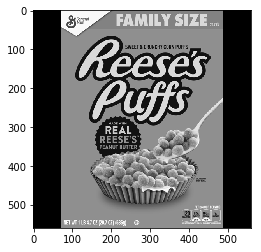

In [3]:
img_reeses = cv2.imread('DATA/reeses_puffs.png',0)
plt.imshow(img_reeses, cmap='gray')

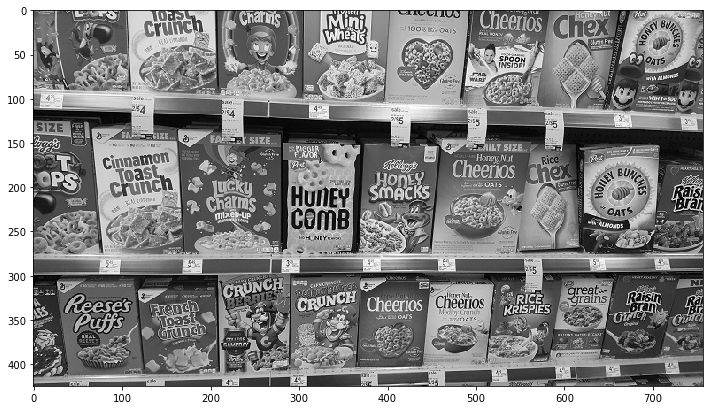

In [4]:
img_cereals = cv2.imread('DATA/many_cereals.jpg',0)
show_img(img_cereals)

**We will explore 3 Methods:**
1. Brute-Force Matching with ORB Descriptors  
2. Brute-Force Matching with SIFT Descriptors and Ratio Test  
3. FLANN based Matcher

# Brute-Force Matching with ORB Descriptors  

In [5]:
orb = cv2.ORB_create()

In [6]:
kp1, des1 = orb.detectAndCompute(img_reeses, None) # Returns Key Points and Description
kp2, des2 = orb.detectAndCompute(img_cereals, None)

print(type(kp1))
print(type(des1))

<class 'list'>
<class 'numpy.ndarray'>


In [7]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)

In [8]:
print(type(matches))
print(len(matches))

<class 'list'>
263


In [9]:
single_match = matches[0]
single_match.distance

78.0

In [10]:
type(single_match)

cv2.DMatch

In [11]:
matches = sorted(matches, key=lambda x:x.distance) # Sorting based on distance

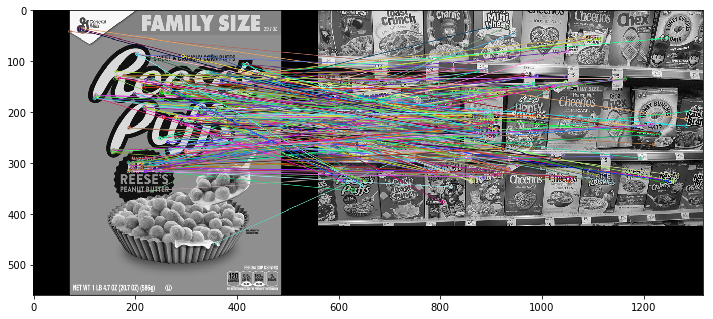

In [12]:
reeces_matches = cv2.drawMatches(img_reeses, kp1, img_cereals, kp2, matches, None, flags=2)
show_img(reeces_matches)

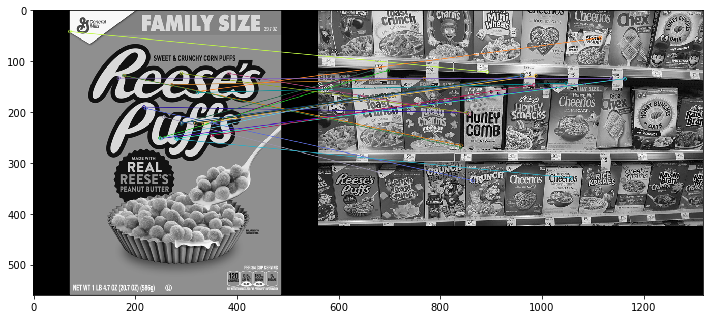

In [13]:
reeces_matches = cv2.drawMatches(img_reeses, kp1, img_cereals, kp2, matches[:25], None, flags=2) # limit number of matchings
show_img(reeces_matches)

# Brute-Force Matching with SIFT Descriptors and Ratio Test  

In [14]:
sift = cv2.xfeatures2d.SIFT_create()

In [15]:
# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img_reeses, None)
kp2, des2 = sift.detectAndCompute(img_cereals,None)

### One way (like ORB)

In [16]:
bf = cv2.BFMatcher()
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x:x.distance) # Sorting based on distance

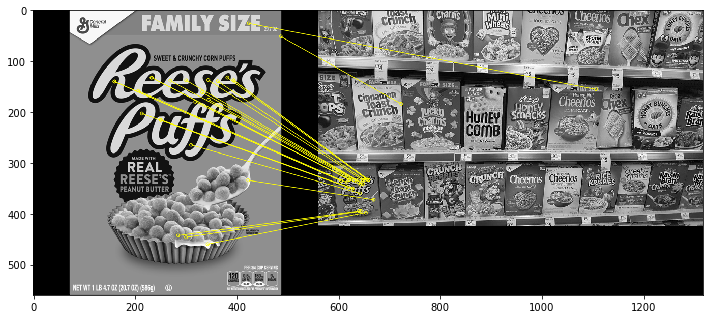

In [17]:
reeces_matches = cv2.drawMatches(img_reeses, kp1, img_cereals, kp2, matches[:25], None, flags=2, matchColor=(255,255,0))
show_img(reeces_matches)

### Another Way (Original way)

In [18]:
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2) # Finds the k best matches for each descriptor from a query set.

In [19]:
print(len(matches))
matches[:3] # Best and 2nd best match in 2 columns

1500


[[<DMatch 00000237CBDA60F0>, <DMatch 00000237CBDDFED0>],
 [<DMatch 00000237CBC0B290>, <DMatch 00000237CBC0B410>],
 [<DMatch 00000237CC9FBC70>, <DMatch 00000237CC9FBBF0>]]

**Now take a ratio test:**
- if distance between best and 2nd best match is LOW, then it is a GOOD feature to match on
- if distance between best and 2nd best match is HIGH, then it is a BAD feature to match on

In [20]:
good = []

for match1, match2 in matches:
    if match1.distance < 0.75*match2.distance:
        good.append([match1])

In [21]:
print(len(good))
good[:3] # Best and 2nd best match in 2 columns

78


[[<DMatch 00000237CC9FFC90>],
 [<DMatch 00000237CCA0D290>],
 [<DMatch 00000237CCA0D2D0>]]

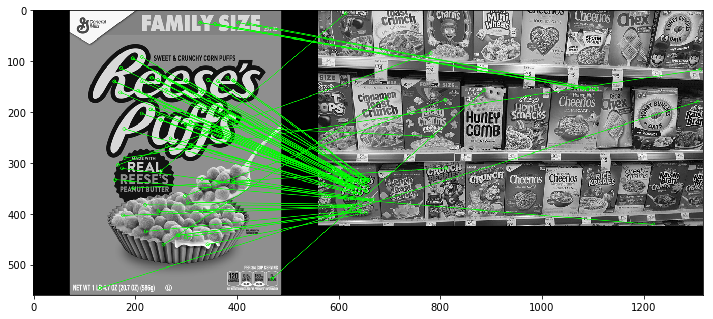

In [22]:
# flag = 0 will show all matches, but only wraw lines on best matches, flag = 2 will only wraw lines on best matches
shift_reeces_matches = cv2.drawMatchesKnn(img_reeses, kp1, img_cereals, kp2, good, None, flags=2, matchColor=(0,255,0))
show_img(shift_reeces_matches)

# FLANN based Matcher

In [23]:
sift = cv2.xfeatures2d.SIFT_create()

In [24]:
# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img_reeses, None)
kp2, des2 = sift.detectAndCompute(img_cereals,None)

In [25]:
# FLANN
# Its not going to find the best possible matches
# Instead it's going to fing general good matches

In [26]:
# Set parameters first (default parameters at first)
FLAN_INDEX_KDTREE = 0
index_params = dict(algorithm=FLAN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)

In [27]:
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2) # Finds the k best matches for each descriptor from a query set.

In [28]:
good = []

for match1, match2 in matches:
    if match1.distance < 0.7*match2.distance:
        good.append([match1])

In [29]:
print(len(good))
good[:3] # Best and 2nd best match in 2 columns

67


[[<DMatch 00000237CBDE4150>],
 [<DMatch 00000237CBDE4190>],
 [<DMatch 00000237CBDE4C90>]]

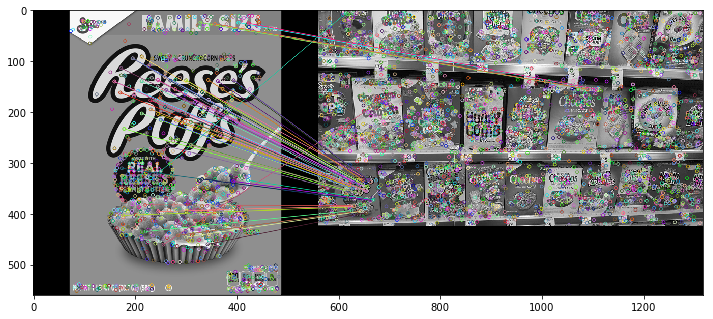

In [30]:
# flag = 0 will show all matches, but only wraw lines on best matches, flag = 2 will only wraw lines on best matches
flann_reeces_matches = cv2.drawMatchesKnn(img_reeses, kp1, img_cereals, kp2, good, None, flags=0)
show_img(flann_reeces_matches)

### Now with masking

In [31]:
matchesMask = [[0,0] for i in range(len(matches))]
# matchesMask

In [32]:
for i, (match1, match2) in enumerate(matches):
    if match1.distance < 0.7*match2.distance:
        matchesMask[i] = [1,0]

In [33]:
drawParams = dict(matchColor = (0,255,0), singlePointColor = (255,0,0), matchesMask = matchesMask, flags = 0)

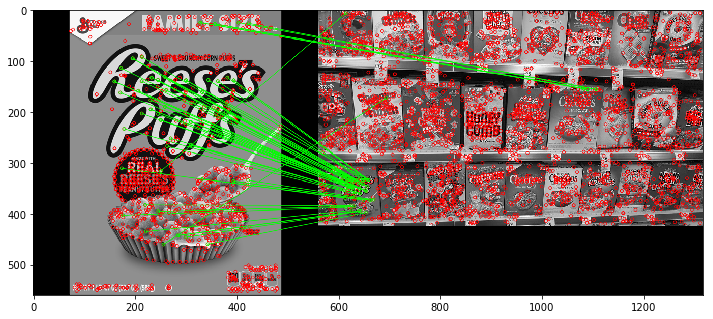

In [34]:
# flag = 0 will show all matches, but only wraw lines on best matches, flag = 2 will only wraw lines on best matches
flann_reeces_matches = cv2.drawMatchesKnn(img_reeses, kp1, img_cereals, kp2, matches, None, **drawParams) 
show_img(flann_reeces_matches)